# Training Log Analysis

This notebook parses CPU and GPU training logs and plots key metrics.

In [12]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [13]:
LOG_DIR = Path("/hpcwork/ro092286/smartsim/mini_app/train_models/model_a")
CPU_LOG = LOG_DIR / "model_a_train_output.log"
GPU_LOG = LOG_DIR / "model_a_train_output_gpu.log"

LINE_RE = re.compile(
    r"^Epoch\s+(?P<epoch>\d+)\/(?P<total>\d+)\s+"
    r"train_loss=(?P<train_loss>[0-9.eE+-]+)\s+"
    r"val_loss=(?P<val_loss>[0-9.eE+-]+)\s+"
    r"lr=(?P<lr>[0-9.eE+-]+)\s+"
    r"improve=(?P<improve>True|False)\s+"
    r"time=(?P<time_s>[0-9.eE+-]+)s\s+"
    r"ETA=(?P<eta_s>[0-9.eE+-]+)s"
)

TRAIN_SAMPLE_RE = re.compile(r"Train dataset size: (?P<train>\d+) samples")
VAL_SAMPLE_RE = re.compile(r"Val dataset size: (?P<val>\d+) samples")
STEPS_RE = re.compile(
    r"Train steps per epoch: (?P<train_global>\d+) \(global\), (?P<train_rank>\d+) \(per-rank\)"
)
VAL_STEPS_RE = re.compile(
    r"Val steps per epoch: (?P<val_global>\d+) \(global\), (?P<val_rank>\d+) \(per-rank\)"
)
SAMPLES_RE = re.compile(
    r"Samples per epoch: (?P<samples_global>\d+) \(global\), (?P<samples_rank>\d+) \(per-rank\)"
)
RES_RE = re.compile(r"Data resolution: (?P<h>\d+)x(?P<w>\d+)")

train_samples = {"cpu": -1, "gpu": -1}
val_samples = {"cpu": -1, "gpu": -1}

def parse_log(path: Path, label: str) -> pd.DataFrame:
    global train_samples, val_samples
    rows = []
    ctx = {
        "train_steps_global": None,
        "train_steps_rank": None,
        "val_steps_global": None,
        "val_steps_rank": None,
        "samples_global": None,
        "samples_rank": None,
        "H": None,
        "W": None,
    }
    for line in path.read_text().splitlines():
        ms = TRAIN_SAMPLE_RE.match(line.strip())
        if ms:
            d = ms.groupdict()
            train_samples[label] = int(d["train"])
        ms = VAL_SAMPLE_RE.match(line.strip())
        if ms:
            d = ms.groupdict()
            val_samples[label] = int(d["val"])
        ms = STEPS_RE.match(line.strip())
        if ms:
            ctx["train_steps_global"] = int(ms.group("train_global"))
            ctx["train_steps_rank"] = int(ms.group("train_rank"))
        ms = VAL_STEPS_RE.match(line.strip())
        if ms:
            ctx["val_steps_global"] = int(ms.group("val_global"))
            ctx["val_steps_rank"] = int(ms.group("val_rank"))
        ms = SAMPLES_RE.match(line.strip())
        if ms:
            ctx["samples_global"] = int(ms.group("samples_global"))
            ctx["samples_rank"] = int(ms.group("samples_rank"))
        ms = RES_RE.match(line.strip())
        if ms:
            ctx["H"] = int(ms.group("h"))
            ctx["W"] = int(ms.group("w"))
        m = LINE_RE.match(line.strip())
        if not m:
            continue
        d = m.groupdict()
        rows.append({
            "label": label,
            "epoch": int(d["epoch"]),
            "total": int(d["total"]),
            "train_loss": float(d["train_loss"]),
            "val_loss": float(d["val_loss"]),
            "lr": float(d["lr"]),
            "improve": d["improve"] == "True",
            "time_s": float(d["time_s"]),
            "eta_s": float(d["eta_s"]),
            **ctx,
        })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values("epoch").reset_index(drop=True)
        df["epoch_time_s"] = df["time_s"].diff()
    return df

cpu_df = parse_log(CPU_LOG, "cpu")
gpu_df = parse_log(GPU_LOG, "gpu")

cpu_solo = parse_log(LOG_DIR / "model_a_train_output_l.log", "cpu_solo")

print("Train samples:" , train_samples)
print("Val samples:", val_samples)

cpu_df.head(), gpu_df.head()

Train samples: {'cpu': 2332800, 'gpu': 23328000, 'cpu_solo': 20995200}
Val samples: {'cpu': 2332800, 'gpu': 23328000, 'cpu_solo': 2332800}


(  label  epoch  total  train_loss  val_loss     lr  improve  time_s   eta_s  \
 0   cpu     11    100    0.217442  0.086991  0.001     True    23.2  2060.6   
 1   cpu     12    100    0.148807  0.057491  0.001     True    44.1  1939.6   
 2   cpu     13    100    0.111750  0.215095  0.001    False    62.0  1799.1   
 3   cpu     14    100    0.109275  0.033793  0.001     True    80.2  1724.1   
 4   cpu     15    100    0.189063  0.039606  0.001    False    98.8  1679.0   
 
    train_steps_global  train_steps_rank  val_steps_global  val_steps_rank  \
 0                9000              9000              1000            1000   
 1                9000              9000              1000            1000   
 2                9000              9000              1000            1000   
 3                9000              9000              1000            1000   
 4                9000              9000              1000            1000   
 
    samples_global  samples_rank    H    W  epoc

## Validation Loss vs Epoch

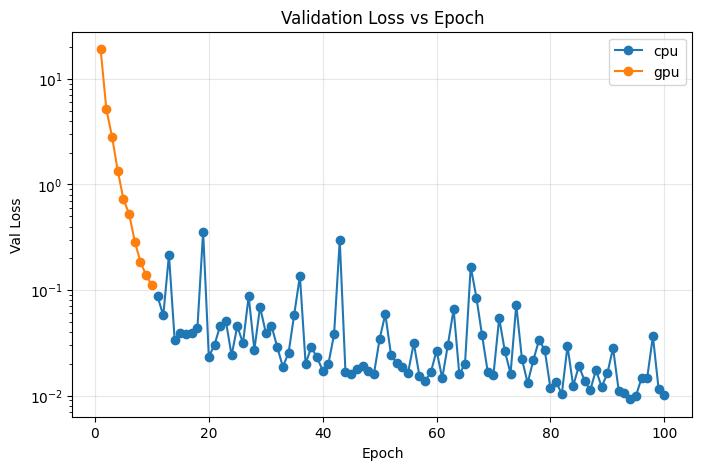

In [14]:
plt.figure(figsize=(8, 5))
for df in (cpu_df, gpu_df):
    if df.empty:
        continue
    plt.plot(df["epoch"], df["val_loss"], marker="o", label=df["label"].iloc[0])
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.yscale("log")
plt.title("Validation Loss vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

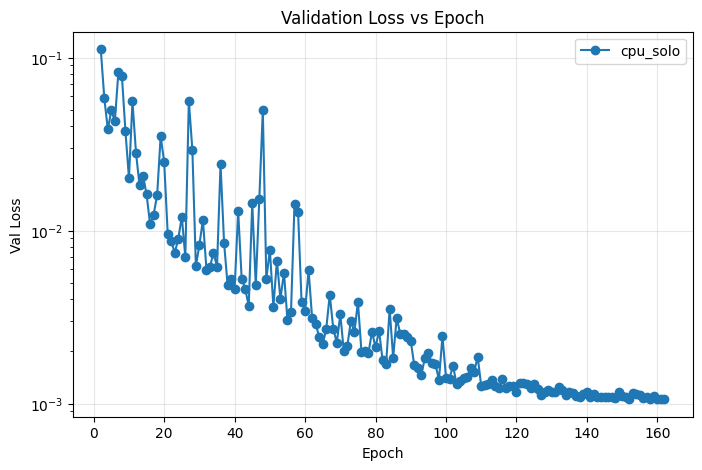

In [16]:
plt.figure(figsize=(8, 5))
for df in [cpu_solo]:
    if df.empty:
        continue
    plt.plot(df["epoch"], df["val_loss"], marker="o", label=df["label"].iloc[0])
plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.yscale("log")
plt.title("Validation Loss vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Epoch Time (Delta of Total Time)

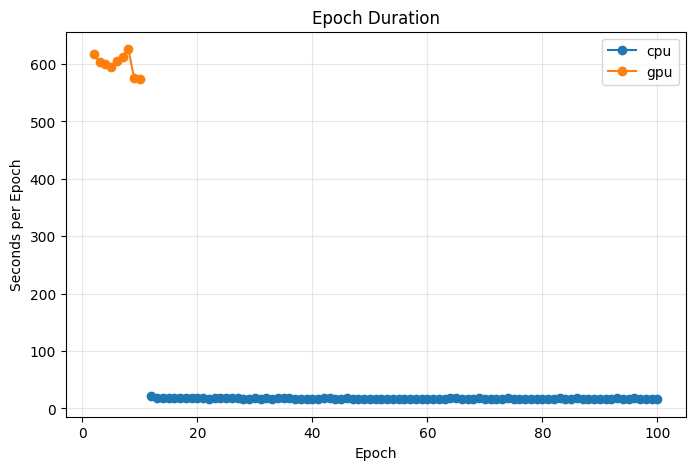

In [ ]:
plt.figure(figsize=(8, 5))
for df in (cpu_df, gpu_df):
    if df.empty:
        continue
    plt.plot(df["epoch"], df["epoch_time_s"], marker="o", label=df["label"].iloc[0])
plt.xlabel("Epoch")
plt.ylabel("Seconds per Epoch")
plt.title("Epoch Duration")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Train Loss vs Epoch

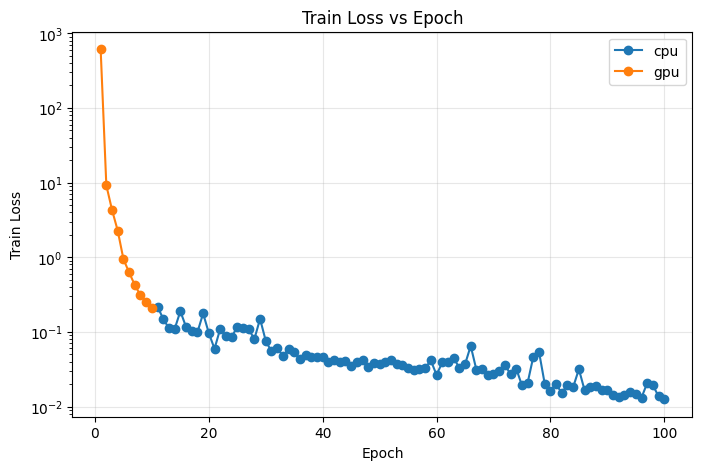

In [ ]:
plt.figure(figsize=(8, 5))
for df in (cpu_df, gpu_df):
    if df.empty:
        continue
    plt.plot(df["epoch"], df["train_loss"], marker="o", label=df["label"].iloc[0])
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.yscale("log")
plt.title("Train Loss vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Learning Rate vs Epoch

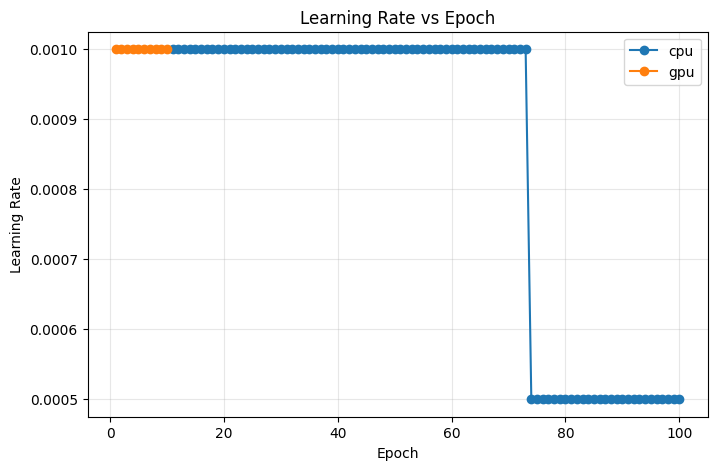

In [ ]:
plt.figure(figsize=(8, 5))
for df in (cpu_df, gpu_df):
    if df.empty:
        continue
    plt.plot(df["epoch"], df["lr"], marker="o", label=df["label"].iloc[0])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Val Loss vs Wall Time

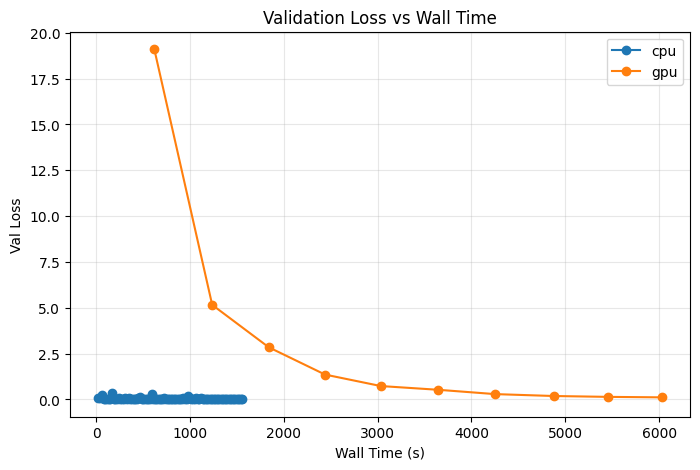

In [ ]:
plt.figure(figsize=(8, 5))
for df in (cpu_df, gpu_df):
    if df.empty:
        continue
    plt.plot(df["time_s"], df["val_loss"], marker="o", label=df["label"].iloc[0])
plt.xlabel("Wall Time (s)")
plt.ylabel("Val Loss")
plt.title("Validation Loss vs Wall Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Samples/s vs Epoch

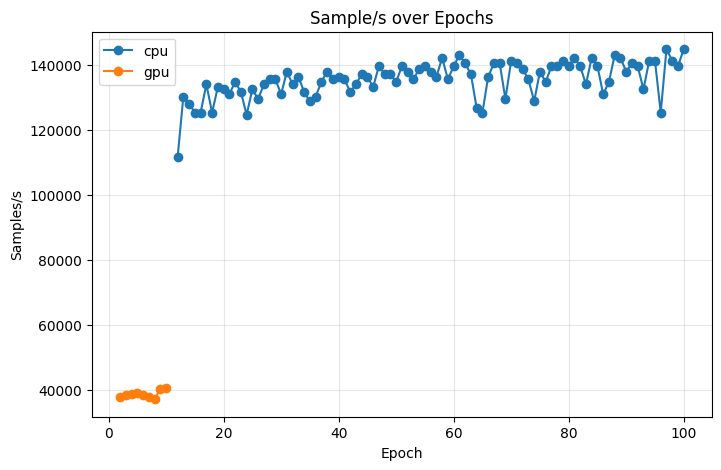

In [ ]:


plt.figure(figsize=(8, 5))
for df in (cpu_df, gpu_df):
    if df.empty:
        continue
    denom = df["epoch_time_s"]
    if "samples_global" in df.columns and df["samples_global"].notna().any():
        df["samples_per_second"] = df["samples_global"] / denom
    else:
        label = df["label"].iloc[0]
        df["samples_per_second"] = train_samples[label] / denom
    plt.plot(df["epoch"], df["samples_per_second"], marker="o", label=df["label"].iloc[0])
plt.xlabel("Epoch")
plt.ylabel("Samples/s")
plt.title("Sample/s over Epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Samples per Epoch (Global)

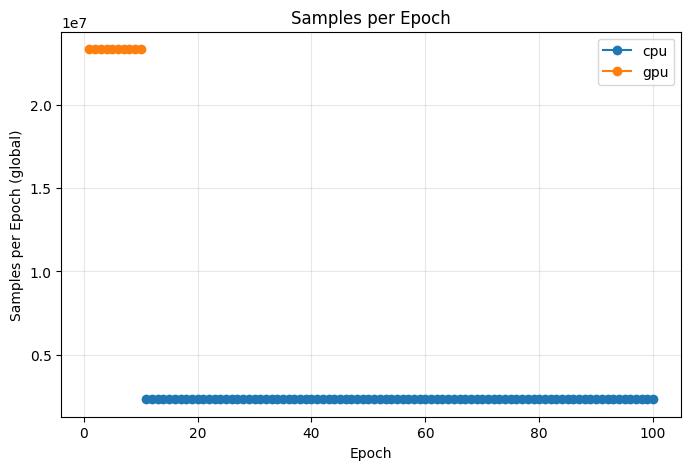

In [ ]:
plt.figure(figsize=(8, 5))
for df in (cpu_df, gpu_df):
    if df.empty:
        continue
    if "samples_global" not in df.columns:
        continue
    plt.plot(df["epoch"], df["samples_global"], marker="o", label=df["label"].iloc[0])
plt.xlabel("Epoch")
plt.ylabel("Samples per Epoch (global)")
plt.title("Samples per Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Train Steps per Epoch (Global)

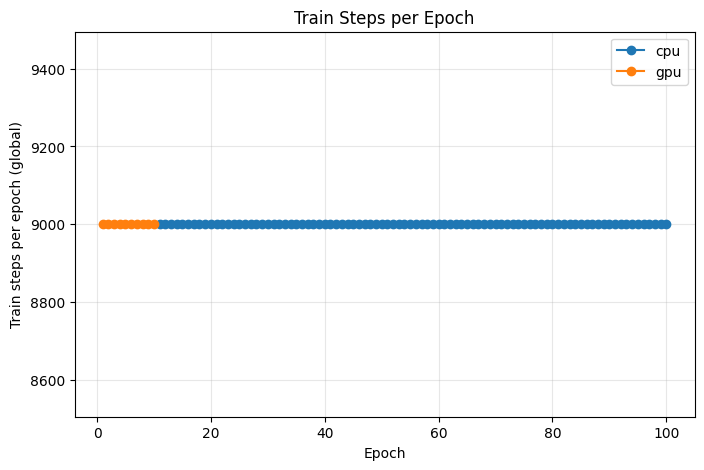

In [ ]:
plt.figure(figsize=(8, 5))
for df in (cpu_df, gpu_df):
    if df.empty:
        continue
    if "train_steps_global" not in df.columns:
        continue
    plt.plot(df["epoch"], df["train_steps_global"], marker="o", label=df["label"].iloc[0])
plt.xlabel("Epoch")
plt.ylabel("Train steps per epoch (global)")
plt.title("Train Steps per Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()